Mounting my Google drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Nessary Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


Loading the data set from google drive
> Add blockquote



In [7]:
file_path = "/content/drive/MyDrive/Work Document/OASIS INFOBYTE/DataAnalytics-L1-EDARetailSales/Sample - Superstore.csv"
# Added encoding parameter to handle non-utf-8 characters
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data Shapes

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.columns
df.info()

Rows: 9994
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null 

Data Cleaning missing value

In [10]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Data Cleaning Duplicate Records

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Data Cleaning Remove Duplicates

In [12]:
df.drop_duplicates(inplace=True)

Descriptive Statistics

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Descriptive Statistics Sales, Profit, Quantity and Discount

In [14]:
df[['Sales','Profit','Quantity','Discount']].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


Convert Date Columns

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Monthly Sales Trend

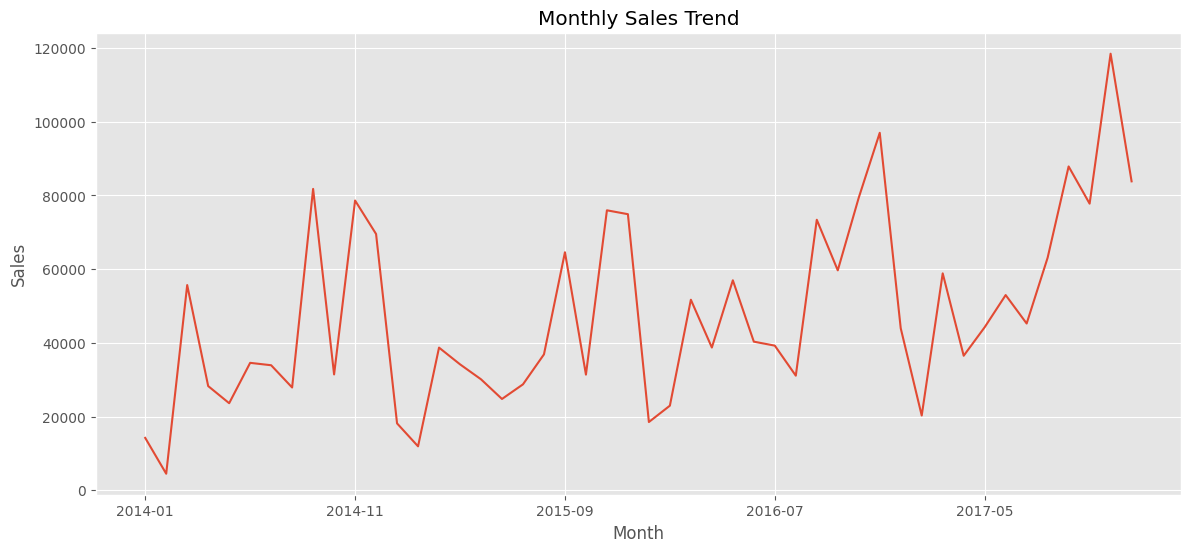

In [16]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Yearly Sales Trend

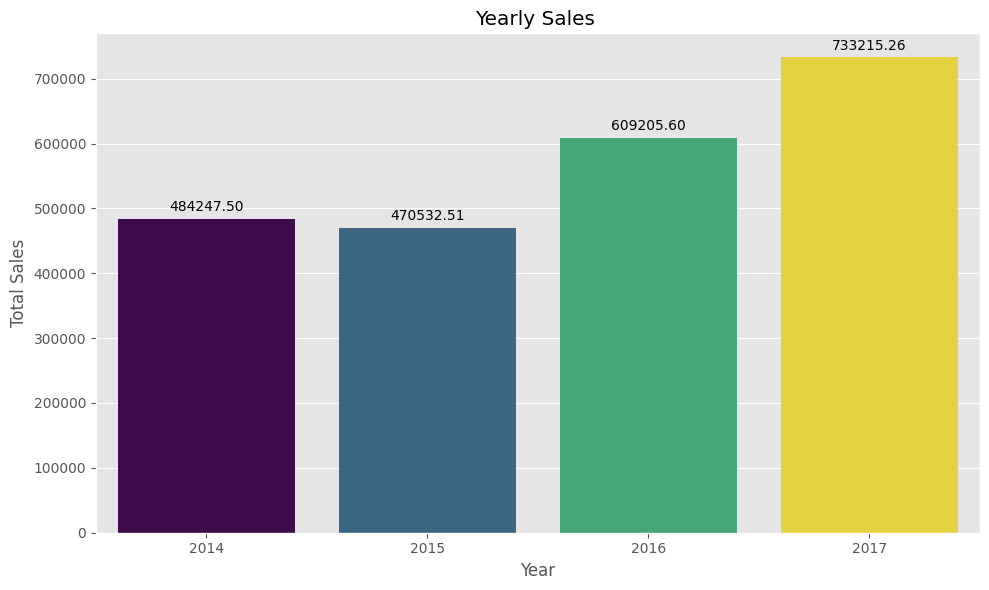

In [40]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    hue=yearly_sales.index,
    palette="viridis",
    legend=False
)

# Adding labels to the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Yearly Sales ")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Sales by Category

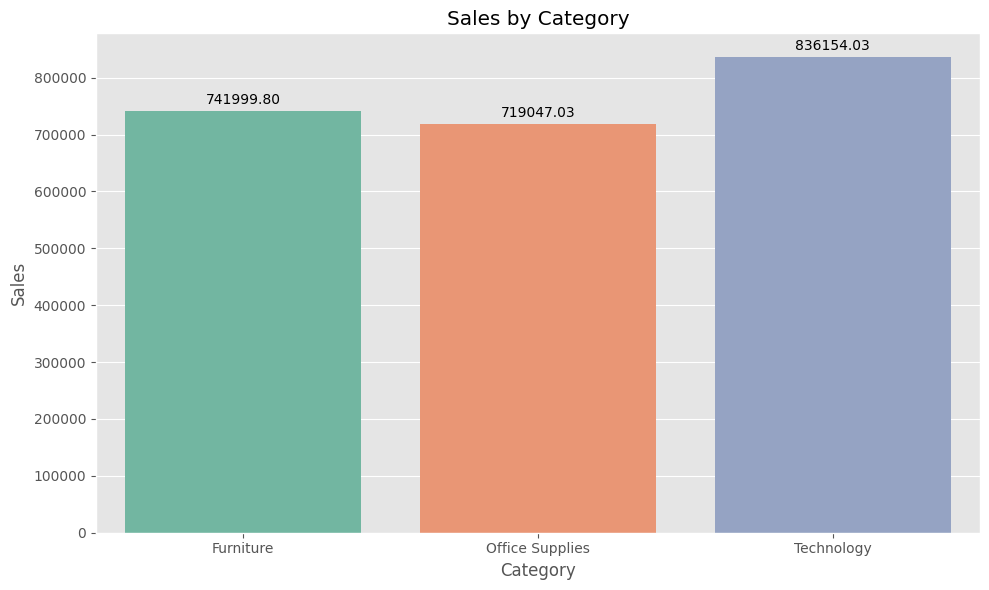

In [23]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette='Set2',
    legend=False
)

# Adding labels to the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Profit by Category

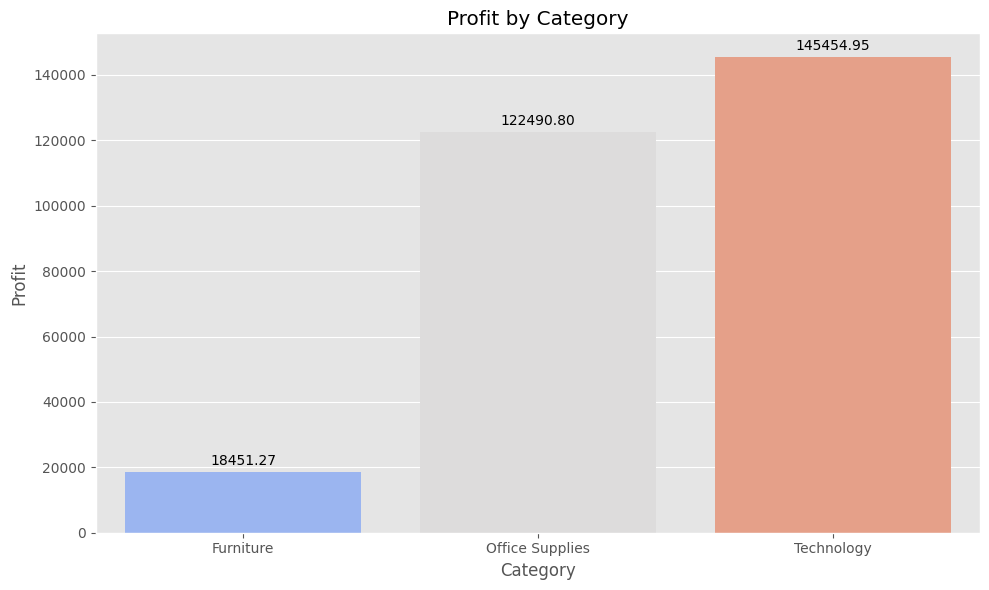

In [22]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    hue=category_profit.index,
    palette='coolwarm',
    legend=False
)

# Adding labels to the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Sales by Region

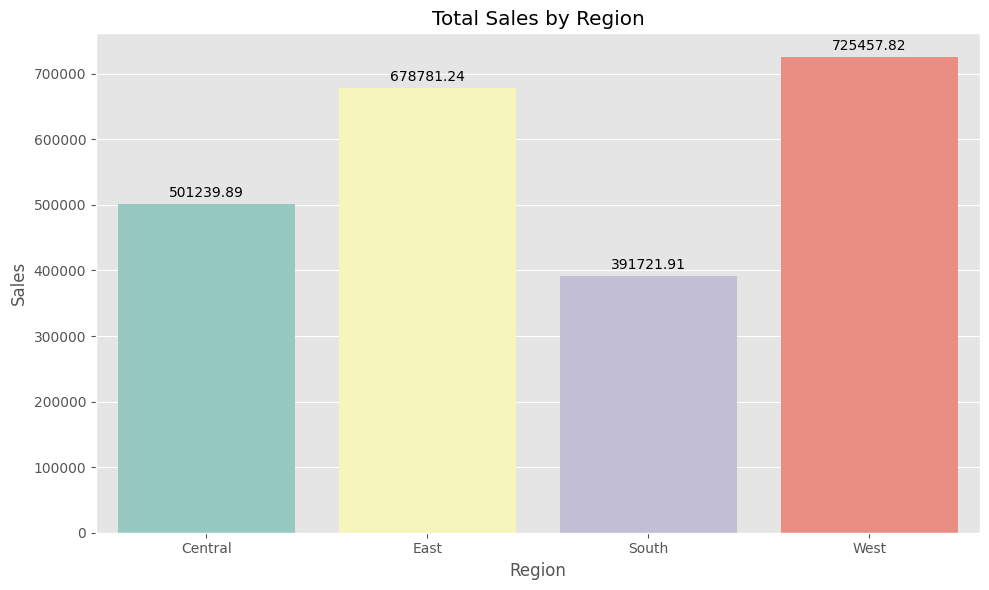

In [25]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette='Set3',
    legend=False
)

# Adding labels to the top of each bar for consistency
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

### Profit by Region

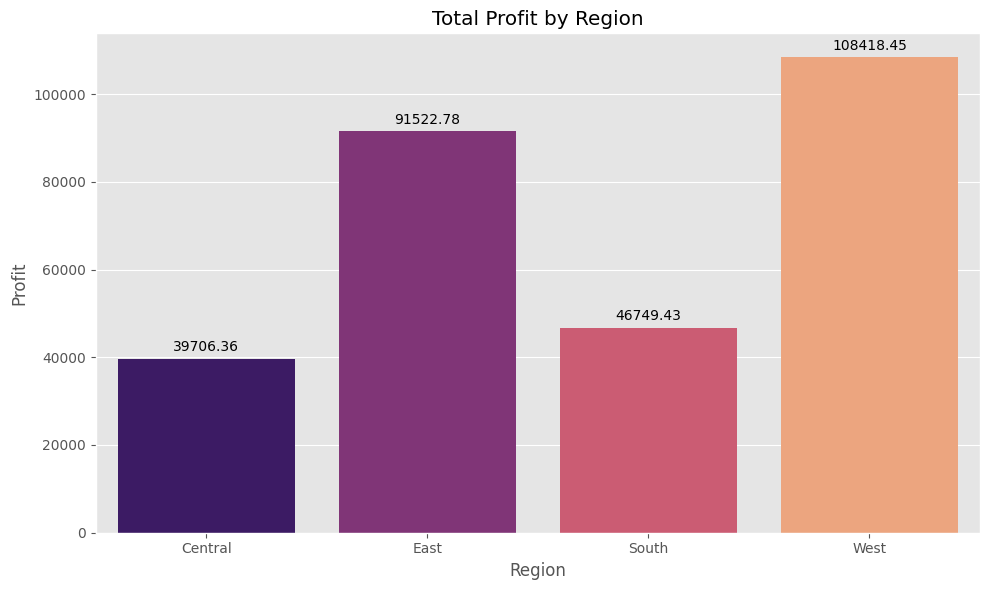

In [27]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=region_profit.index,
    y=region_profit.values,
    hue=region_profit.index,
    palette='magma',
    legend=False
)

# Adding labels to the top of each bar for consistency
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Total Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

### Sales by Customer Segment

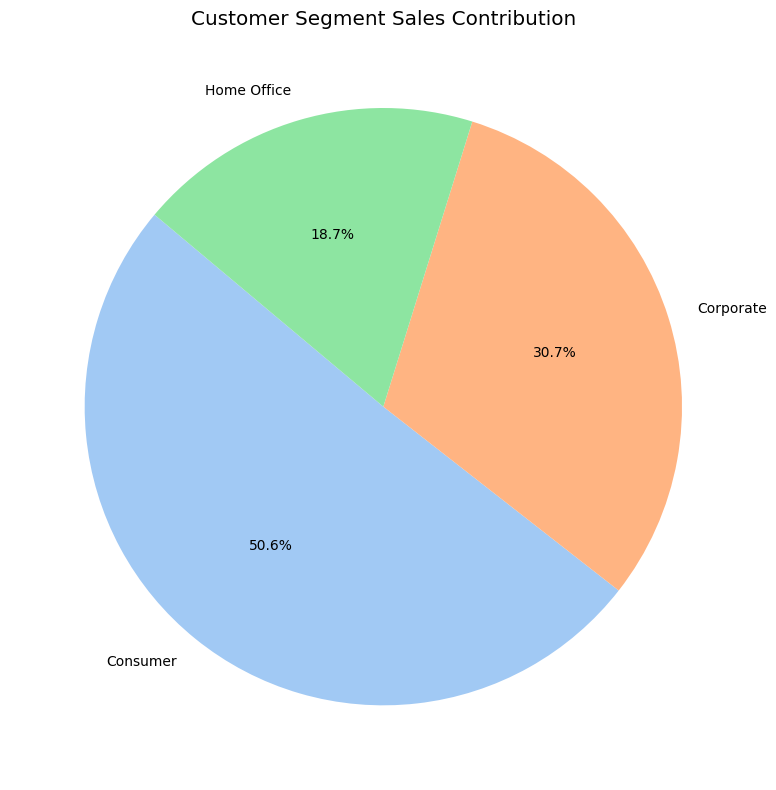

In [28]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)

plt.title("Customer Segment Sales Contribution")
plt.tight_layout()
plt.show()

### Top 10 Selling Products

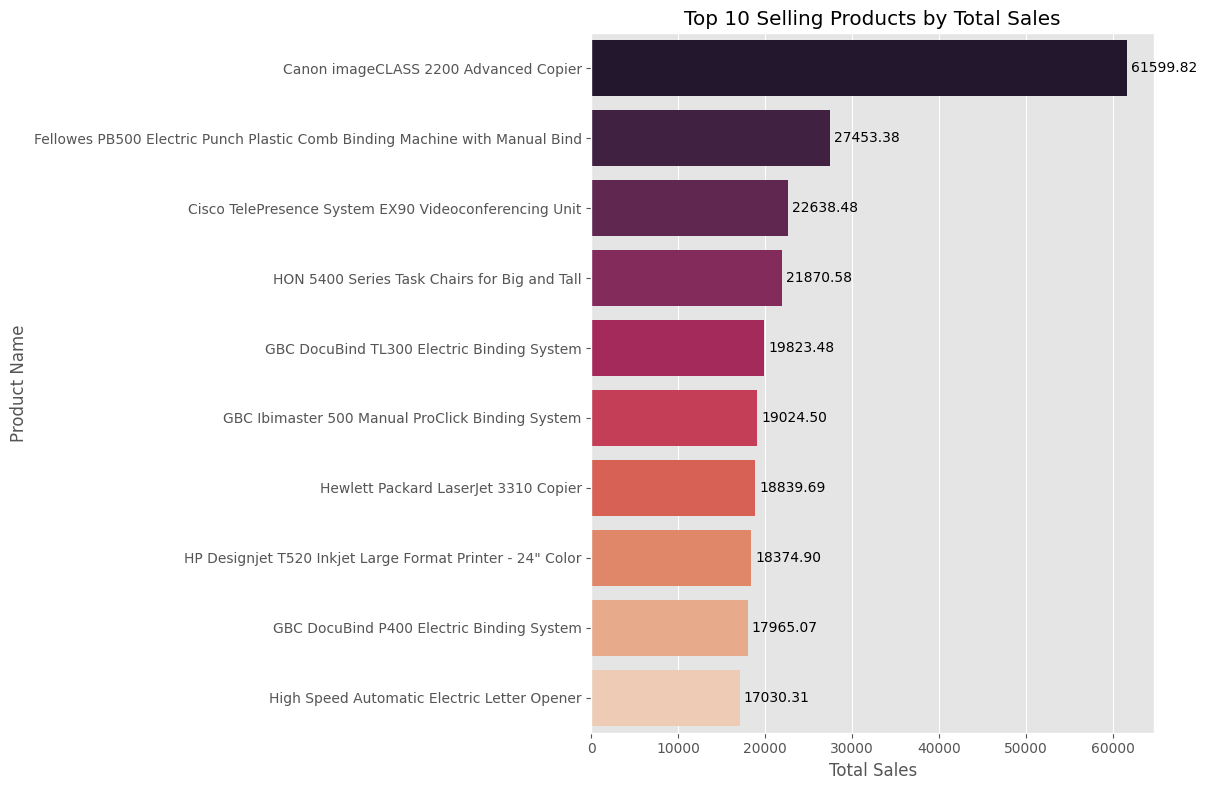

In [29]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='rocket',
    legend=False
)

# Adding labels to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Top 10 Selling Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

### Top 10 Least Profitable Products (Highest Losses)

/tmp/ipykernel_6011/2755341151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


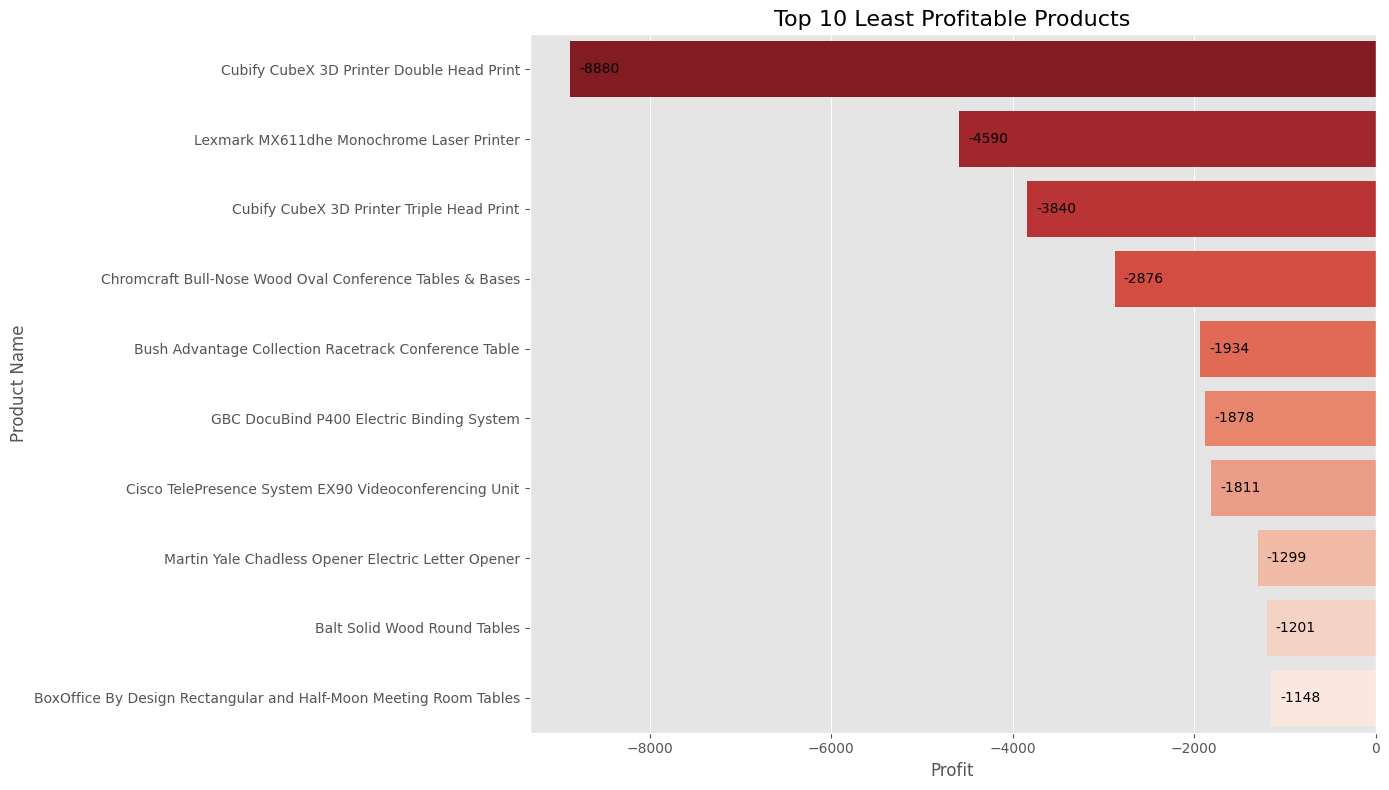

In [33]:
least_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=least_profit_products.values,
    y=least_profit_products.index,
    palette='Reds_r'
)

plt.title("Top 10 Least Profitable Products", fontsize=16)
plt.xlabel("Profit")
plt.ylabel("Product Name")

# Add labels inside bars
for i, value in enumerate(least_profit_products.values):
    ax.text(
        value + 100,      # moves text slightly right
        i,
        f'{value:.0f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Discount and Profit Analysis

To understand how discounts affect profitability, three visualizations were created:

1. Average Profit by Discount
2. Discount vs Profit with Trend Line
3. Correlation Heatmap

### Key Findings

- Increasing discounts generally reduce profitability.
- High-discount transactions often generate lower profits or losses.
- The trend line confirms a negative relationship between Discount and Profit.
- Correlation analysis further supports the impact of discounting on profitability.

### Average Profit by Discount Level

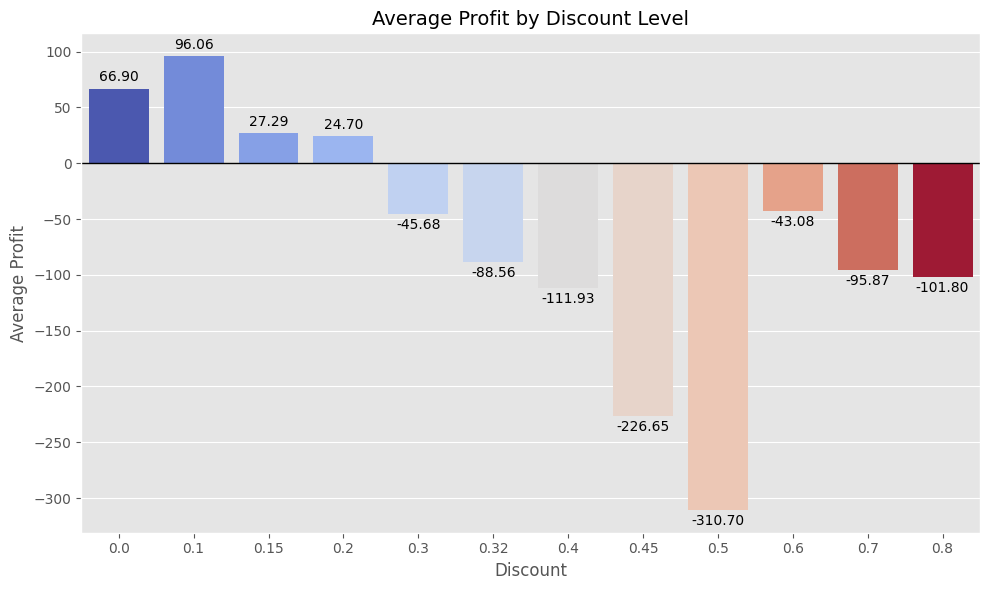

In [35]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=discount_profit,
    x='Discount',
    y='Profit',
    hue='Discount',
    palette='coolwarm',
    legend=False
)

plt.title('Average Profit by Discount Level', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.axhline(0, color='black', linewidth=1)

# Adding data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Discount vs Profit with Trend Line

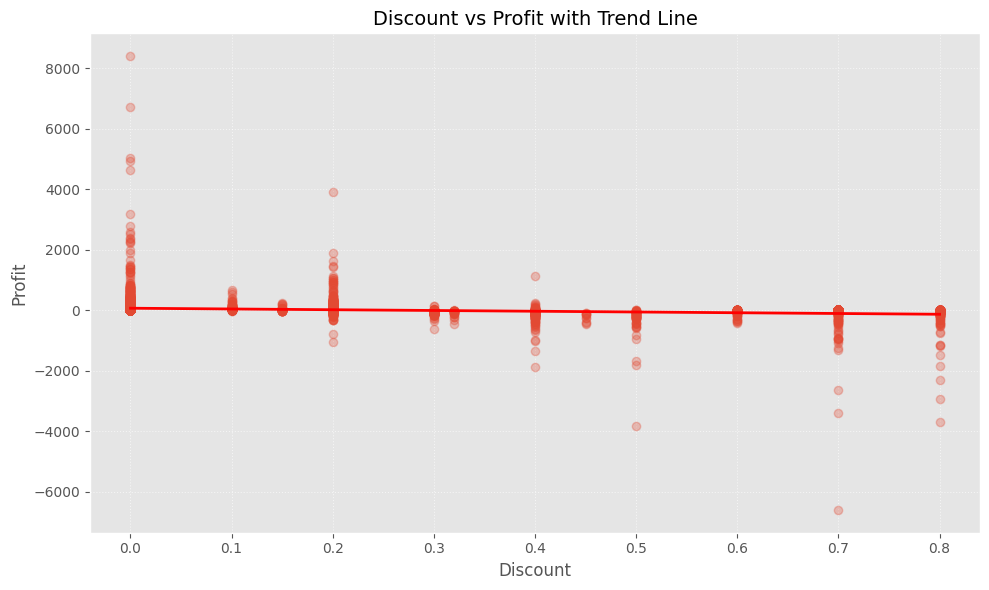

In [36]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Discount vs Profit with Trend Line', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Correlation Heatmap
Exploring the relationships between Sales, Profit, Quantity, and Discount.

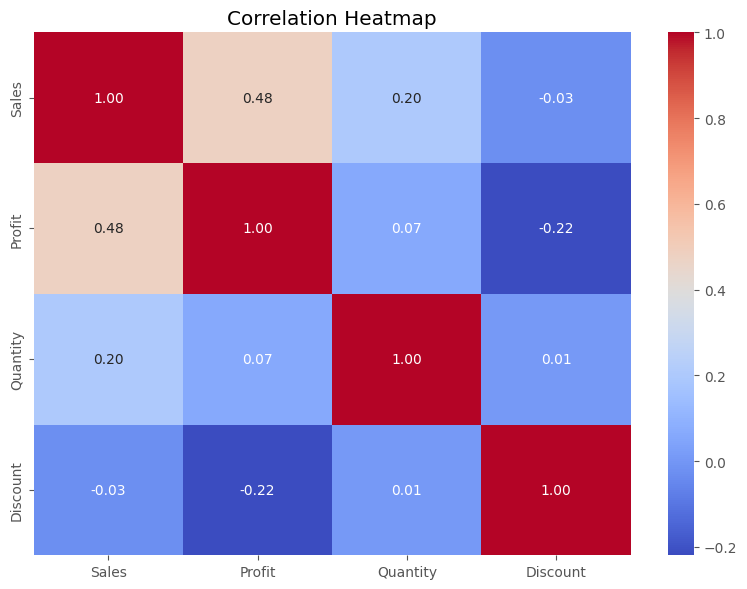

In [37]:
corr_matrix = df[['Sales','Profit','Quantity','Discount']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [38]:
corr = df[['Sales','Profit','Quantity','Discount']].corr()
display(corr)

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479064,0.200795,-0.028190
Profit,0.479064,1.000000,0.066253,-0.219487
Quantity,0.200795,0.066253,1.000000,0.008623
Discount,-0.028190,-0.219487,0.008623,1.000000


## Final Business Insights

Based on the Exploratory Data Analysis, here are the answers to the key business questions:

1. **Highest Sales Region:** The **West** region leads in total sales (~$725,457).
2. **Most Profitable Category:** **Technology** is the most profitable category (~$145,454), followed closely by Office Supplies.
3. **Products Causing Losses:** The **Cubify CubeX 3D Printer** (Double Head Print) is the top loss-making product, with total losses exceeding -$8,800. Tables and certain 3D printers are generally problematic.
4. **Effect of Discount on Profit:** There is a **negative correlation (-0.22)** between discount and profit. Average profit remains positive for discounts up to 20%, but turns into significant losses for discounts of 30% or higher (peaking at 50% discount).
5. **Best-Performing Customer Segment:** The **Consumer** segment is the largest contributor, accounting for **50.6%** of total sales.